In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed_v2.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed_v2.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 17)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


---
# 챌린지 알림 오픈 후 24시간 탐색률이 낮은 이유

In [5]:
# 첫 챌린지 알림 오픈 시점 생성

# 복사
e = event_df.copy()

# 날짜 타입 정리
e["event_time"] = pd.to_datetime(e["event_time"])

# 로그 장애 기간 제외
if "is_log_issue_period" in e.columns:
    e_valid = e[~e["is_log_issue_period"].fillna(False)].copy()
else:
    e_valid = e.copy()

# 챌린지 알림 오픈 로그만 추출
challenge_open = e_valid[
    (e_valid["notification_type"] == "챌린지_알림")
    & (e_valid["event_type"] == "알림오픈")
].copy()

# 유저별 첫 챌린지 알림 오픈 시점
first_challenge_open = (
    challenge_open
    .groupby("user_id")["event_time"]
    .min()
    .reset_index()
    .rename(columns={"event_time": "first_challenge_open_time"})
)

print("챌린지 알림 오픈 로그 수:", len(challenge_open))
print("챌린지 알림을 1회 이상 오픈한 유저 수:", first_challenge_open["user_id"].nunique())

display(first_challenge_open.head())

챌린지 알림 오픈 로그 수: 8141
챌린지 알림을 1회 이상 오픈한 유저 수: 3643


,user_id,first_challenge_open_time
0,U0000001,2025-02-21 12:59:00
1,U0000004,2025-02-25 11:03:00
2,U0000005,2025-04-06 10:31:00
3,U0000011,2025-04-10 14:17:00
4,U0000019,2025-02-11 19:35:00


In [6]:
# 챌린지 알림 오픈 후 24시간 내 첫 앱 내 행동

# 앱 내 행동 이벤트 정의
# 알림수신/알림오픈은 제외
app_events = e_valid[
    e_valid["event_type"].notna()
    & ~e_valid["event_type"].isin(["알림수신", "알림오픈"])
].copy()

# 첫 챌린지 알림 오픈 시점 붙이기
after_open_events = app_events.merge(
    first_challenge_open,
    on="user_id",
    how="inner"
)

# 오픈 이후 24시간 내 이벤트만 필터링
after_open_24h = after_open_events[
    (after_open_events["event_time"] > after_open_events["first_challenge_open_time"])
    & (after_open_events["event_time"] <= after_open_events["first_challenge_open_time"] + pd.Timedelta(hours=24))
].copy()

# 유저별 오픈 후 첫 번째 앱 내 행동
first_after_open_24h = (
    after_open_24h
    .sort_values(["user_id", "event_time"])
    .groupby("user_id")
    .first()
    .reset_index()
)

first_after_open_24h = first_after_open_24h[
    ["user_id", "first_challenge_open_time", "event_time", "event_type", "session_id"]
].rename(columns={
    "event_time": "first_app_event_after_open_time",
    "event_type": "first_app_event_after_open_type"
})

display(first_after_open_24h.head())

,user_id,first_challenge_open_time,first_app_event_after_open_time,first_app_event_after_open_type,session_id
0,U0000001,2025-02-21 12:59:00,2025-02-21 13:02:22,앱실행,da3cf8f436
1,U0000004,2025-02-25 11:03:00,2025-02-25 11:21:15,앱실행,4531423c90
2,U0000005,2025-04-06 10:31:00,2025-04-06 13:24:57,앱실행,a2d0c8f479
3,U0000011,2025-04-10 14:17:00,2025-04-10 16:47:36,앱실행,10c58a3edb
4,U0000019,2025-02-11 19:35:00,2025-02-11 20:29:59,챌린지_탐색,83d240fe12


In [7]:
# 전체 오픈 유저 기준으로 붙이기
open_user_first_action = first_challenge_open.merge(
    first_after_open_24h,
    on=["user_id", "first_challenge_open_time"],
    how="left"
)

# 24시간 내 앱 내 행동이 없는 유저 표시
open_user_first_action["first_app_event_after_open_type"] = (
    open_user_first_action["first_app_event_after_open_type"]
    .fillna("24시간 내 앱내행동 없음")
)

# 첫 행동 분포
first_action_summary = (
    open_user_first_action["first_app_event_after_open_type"]
    .value_counts(dropna=False)
    .reset_index()
)

first_action_summary.columns = ["first_action_after_open", "user_count"]
first_action_summary["ratio"] = first_action_summary["user_count"] / len(open_user_first_action)

display(first_action_summary)

,first_action_after_open,user_count,ratio
0,앱실행,3182,0.873456
1,24시간 내 앱내행동 없음,388,0.106506
2,수면기록,26,0.007137
3,운동기록,14,0.003843
4,마음챙김,11,0.003019
5,챌린지_탐색,9,0.002470
6,식단기록,5,0.001372
7,챌린지참여,5,0.001372
8,온보딩_완료,3,0.000823


### 오픈 후 10분/1시간/24시간 내 행동 발생률 보기
1. 앱 내 행동이 1개라도 있었는가
2. 앱실행 외 추가 행동이 있었는가
3. 챌린지_탐색이 있었는가
4. 챌린지참여가 있었는가
5. 앱실행만 하고 끝났는가
6. 아무 앱 내 행동도 없었는가

In [8]:
# 오픈 후 시간창별 행동 발생률

# 앱 내 행동 이벤트
# 알림수신/알림오픈 제외
app_events = e_valid[
    e_valid["event_type"].notna()
    & ~e_valid["event_type"].isin(["알림수신", "알림오픈"])
].copy()

# 첫 챌린지 알림 오픈 시점 붙이기
after_open_events = app_events.merge(
    first_challenge_open,
    on="user_id",
    how="inner"
)

# 오픈 이후 이벤트만
after_open_events = after_open_events[
    after_open_events["event_time"] > after_open_events["first_challenge_open_time"]
].copy()

after_open_events["minutes_after_open"] = (
    after_open_events["event_time"] - after_open_events["first_challenge_open_time"]
).dt.total_seconds() / 60

In [9]:
def summarize_after_open_window(after_open_events, first_challenge_open, minutes):
    temp = after_open_events[
        after_open_events["minutes_after_open"] <= minutes
    ].copy()

    user_flags = (
        temp
        .groupby("user_id")
        .agg(
            app_event_count=("event_type", "size"),
            non_launch_event_count=("event_type", lambda x: (x != "앱실행").sum()),
            has_challenge_explore=("event_type", lambda x: (x == "챌린지_탐색").any()),
            has_challenge_join=("event_type", lambda x: (x == "챌린지참여").any()),
            has_app_launch=("event_type", lambda x: (x == "앱실행").any())
        )
        .reset_index()
    )

    result = first_challenge_open[["user_id"]].merge(
        user_flags,
        on="user_id",
        how="left"
    )

    result["app_event_count"] = result["app_event_count"].fillna(0).astype(int)
    result["non_launch_event_count"] = result["non_launch_event_count"].fillna(0).astype(int)

    for col in ["has_challenge_explore", "has_challenge_join", "has_app_launch"]:
        result[col] = result[col].fillna(False).astype(bool)

    result["has_any_app_event"] = result["app_event_count"] > 0
    result["has_non_launch_event"] = result["non_launch_event_count"] > 0

    # 앱실행만 있고 추가 행동은 없는 경우
    result["only_app_launch"] = (
        result["has_app_launch"]
        & (result["non_launch_event_count"] == 0)
    )

    # 아무 앱 내 행동도 없는 경우
    result["no_app_event"] = result["app_event_count"] == 0

    summary = pd.DataFrame({
        "window": [f"{minutes}분"],
        "open_user_count": [len(result)],
        "has_any_app_event_rate": [result["has_any_app_event"].mean()],
        "has_non_launch_event_rate": [result["has_non_launch_event"].mean()],
        "challenge_explore_rate": [result["has_challenge_explore"].mean()],
        "challenge_join_rate": [result["has_challenge_join"].mean()],
        "only_app_launch_rate": [result["only_app_launch"].mean()],
        "no_app_event_rate": [result["no_app_event"].mean()]
    })

    return summary, result

In [10]:
summary_10m, user_10m = summarize_after_open_window(
    after_open_events,
    first_challenge_open,
    minutes=10
)

summary_1h, user_1h = summarize_after_open_window(
    after_open_events,
    first_challenge_open,
    minutes=60
)

summary_24h, user_24h = summarize_after_open_window(
    after_open_events,
    first_challenge_open,
    minutes=24 * 60
)

window_summary = pd.concat(
    [summary_10m, summary_1h, summary_24h],
    ignore_index=True
)

display(window_summary)

,window,open_user_count,has_any_app_event_rate,has_non_launch_event_rate,challenge_explore_rate,challenge_join_rate,only_app_launch_rate,no_app_event_rate
0,10분,3643,0.034587,0.024430,0.004941,0.005215,0.010156,0.965413
1,60분,3643,0.163052,0.115015,0.025803,0.029920,0.048037,0.836948
2,1440분,3643,0.893494,0.762009,0.240736,0.268460,0.131485,0.106506


- 오픈 직후 10분 / 1시간 안에는 행동이 거의 안 잡힘
- 24시간까지 보면 챌린지 탐색률은 24.1%, 참여율은 26.8%
- -> 오픈 직후 탐색률이 낮고, 행동이 지연되어 발생함


In [11]:
# 오픈 후 24시간 내 첫 번째 앱실행 외 행동

# 앱실행까지 제외한 실제 기능 행동
non_launch_after_open_24h = after_open_events[
    (after_open_events["minutes_after_open"] <= 24 * 60)
    & (after_open_events["event_type"] != "앱실행")
].copy()

# 유저별 첫 번째 앱실행 외 행동
first_non_launch_24h = (
    non_launch_after_open_24h
    .sort_values(["user_id", "event_time"])
    .groupby("user_id")
    .first()
    .reset_index()
)

first_non_launch_24h = first_non_launch_24h[
    ["user_id", "first_challenge_open_time", "event_time", "event_type", "minutes_after_open"]
].rename(columns={
    "event_time": "first_non_launch_event_time",
    "event_type": "first_non_launch_event_type",
    "minutes_after_open": "first_non_launch_minutes_after_open"
})

display(first_non_launch_24h.head())

,user_id,first_challenge_open_time,first_non_launch_event_time,first_non_launch_event_type,first_non_launch_minutes_after_open
0,U0000001,2025-02-21 12:59:00,2025-02-21 13:02:52,운동기록,3.866667
1,U0000004,2025-02-25 11:03:00,2025-02-25 11:21:45,운동기록,18.750000
2,U0000005,2025-04-06 10:31:00,2025-04-06 13:25:27,식단기록,174.450000
3,U0000011,2025-04-10 14:17:00,2025-04-10 16:48:06,운동기록,151.100000
4,U0000019,2025-02-11 19:35:00,2025-02-11 20:29:59,챌린지_탐색,54.983333


In [12]:
# 전체 챌린지 알림 오픈 유저 기준으로 붙이기
open_user_first_non_launch = first_challenge_open.merge(
    first_non_launch_24h,
    on=["user_id", "first_challenge_open_time"],
    how="left"
)

open_user_first_non_launch["first_non_launch_event_type"] = (
    open_user_first_non_launch["first_non_launch_event_type"]
    .fillna("24시간 내 앱실행 외 행동 없음")
)

first_non_launch_summary = (
    open_user_first_non_launch["first_non_launch_event_type"]
    .value_counts(dropna=False)
    .reset_index()
)

first_non_launch_summary.columns = ["first_non_launch_action_24h", "user_count"]
first_non_launch_summary["ratio"] = (
    first_non_launch_summary["user_count"] / len(open_user_first_non_launch)
)

display(first_non_launch_summary)

,first_non_launch_action_24h,user_count,ratio
0,수면기록,1289,0.353829
1,24시간 내 앱실행 외 행동 없음,867,0.237991
2,운동기록,481,0.132034
3,마음챙김,419,0.115015
4,식단기록,264,0.072468
5,챌린지_탐색,196,0.053802
6,온보딩_완료,68,0.018666
7,챌린지참여,59,0.016195


In [ ]:
# 첫 앱실행 외 행동까지 걸린 시간
time_to_first_non_launch = (
    open_user_first_non_launch
    .loc[
        open_user_first_non_launch["first_non_launch_event_type"] != "24시간 내 앱실행 외 행동 없음",
        "first_non_launch_minutes_after_open"
    ]
    .describe()
)

display(time_to_first_non_launch)

count    2776.000000
mean      450.978812
std       418.241991
min         0.083333
25%       108.183333
50%       292.675000
75%       752.991667
max      1437.500000
Name: first_non_launch_minutes_after_open, dtype: float64

- 챌린지 알림을 열었더라도 유저의 첫 행동은 챌린지보다 기록은 경우가 많음
- 첫 앱실행 외 행동까지 걸린 시간 
    - 중앙값 : 약 4.9시간
    - 75% : 약 12.5시간

---
### 오픈후 24시간 행동 경로 분류
1. 24시간 내 아무 앱 내 행동 없음
2. 앱실행만 있음
3. 기록 행동만 있음
4. 챌린지 탐색만 있음
5. 챌린지 참여만 있음
6. 챌린지 탐색 후 참여
7. 챌린지 참여 후 탐색
8. 기록 행동 + 챌린지 행동 모두 있음

In [14]:
# 오픈 후 24시간 행동 경로 분류

after_open_24h = after_open_events[
    after_open_events["minutes_after_open"] <= 24 * 60
].copy()

# 주요 행동별 첫 발생 시간
def first_time_of_event(df, event_name, col_name):
    return (
        df[df["event_type"] == event_name]
        .groupby("user_id")["event_time"]
        .min()
        .rename(col_name)
        .reset_index()
    )

first_explore = first_time_of_event(
    after_open_24h,
    "챌린지_탐색",
    "first_explore_time_24h"
)

first_join = first_time_of_event(
    after_open_24h,
    "챌린지참여",
    "first_join_time_24h"
)

# 기록 행동 첫 발생 시간
record_events = ["수면기록", "운동기록", "식단기록", "마음챙김"]

first_record = (
    after_open_24h[after_open_24h["event_type"].isin(record_events)]
    .groupby("user_id")["event_time"]
    .min()
    .rename("first_record_time_24h")
    .reset_index()
)

# 앱실행 여부 및 앱 내 행동 수
base_24h = (
    after_open_24h
    .groupby("user_id")
    .agg(
        app_event_count_24h=("event_type", "size"),
        has_app_launch_24h=("event_type", lambda x: (x == "앱실행").any()),
        non_launch_event_count_24h=("event_type", lambda x: (x != "앱실행").sum())
    )
    .reset_index()
)

path_df = first_challenge_open[["user_id", "first_challenge_open_time"]].copy()

path_df = path_df.merge(base_24h, on="user_id", how="left")
path_df = path_df.merge(first_explore, on="user_id", how="left")
path_df = path_df.merge(first_join, on="user_id", how="left")
path_df = path_df.merge(first_record, on="user_id", how="left")

# 결측 처리
path_df["app_event_count_24h"] = path_df["app_event_count_24h"].fillna(0).astype(int)
path_df["non_launch_event_count_24h"] = path_df["non_launch_event_count_24h"].fillna(0).astype(int)
path_df["has_app_launch_24h"] = path_df["has_app_launch_24h"].fillna(False).astype(bool)

path_df["has_explore_24h"] = path_df["first_explore_time_24h"].notna()
path_df["has_join_24h"] = path_df["first_join_time_24h"].notna()
path_df["has_record_24h"] = path_df["first_record_time_24h"].notna()

path_df["has_challenge_action_24h"] = (
    path_df["has_explore_24h"] | path_df["has_join_24h"]
)

path_df["only_app_launch_24h"] = (
    path_df["has_app_launch_24h"]
    & (path_df["non_launch_event_count_24h"] == 0)
)

path_df["no_app_event_24h"] = path_df["app_event_count_24h"] == 0

In [15]:
# =========================
# 경로 분류 함수
# =========================

def classify_path(row):
    if row["no_app_event_24h"]:
        return "24시간 내 앱내행동 없음"
    
    if row["only_app_launch_24h"]:
        return "앱실행만 있음"
    
    has_record = row["has_record_24h"]
    has_explore = row["has_explore_24h"]
    has_join = row["has_join_24h"]
    
    if has_record and not has_explore and not has_join:
        return "기록 행동만 있음"
    
    if has_explore and not has_join:
        return "챌린지 탐색만 있음"
    
    if has_join and not has_explore:
        return "챌린지 참여만 있음"
    
    if has_explore and has_join:
        if row["first_explore_time_24h"] <= row["first_join_time_24h"]:
            return "챌린지 탐색 후 참여"
        else:
            return "챌린지 참여 후 탐색"
    
    return "기타 행동만 있음"


path_df["path_24h"] = path_df.apply(classify_path, axis=1)

path_summary = (
    path_df["path_24h"]
    .value_counts()
    .reset_index()
)

path_summary.columns = ["path_24h", "user_count"]
path_summary["ratio"] = path_summary["user_count"] / len(path_df)

display(path_summary)

,path_24h,user_count,ratio
0,기록 행동만 있음,1785,0.489981
1,챌린지 탐색 후 참여,784,0.215207
2,앱실행만 있음,479,0.131485
3,24시간 내 앱내행동 없음,388,0.106506
4,챌린지 참여만 있음,114,0.031293
5,챌린지 참여 후 탐색,80,0.021960
6,챌린지 탐색만 있음,13,0.003568


In [16]:
# 챌린지 참여 유저 중 탐색을 거쳤는지 확인
join_users_24h = path_df[path_df["has_join_24h"]].copy()

join_path_summary = (
    join_users_24h
    .assign(
        join_type=np.select(
            [
                join_users_24h["has_explore_24h"] 
                & (join_users_24h["first_explore_time_24h"] <= join_users_24h["first_join_time_24h"]),
                
                join_users_24h["has_explore_24h"] 
                & (join_users_24h["first_explore_time_24h"] > join_users_24h["first_join_time_24h"]),
                
                ~join_users_24h["has_explore_24h"]
            ],
            [
                "탐색 후 참여",
                "참여 후 탐색",
                "탐색 없이 참여"
            ],
            default="기타"
        )
    )
    ["join_type"]
    .value_counts()
    .reset_index()
)

join_path_summary.columns = ["join_type", "user_count"]
join_path_summary["ratio_among_join_users"] = (
    join_path_summary["user_count"] / len(join_users_24h)
)

display(join_path_summary)

,join_type,user_count,ratio_among_join_users
0,탐색 후 참여,784,0.801636
1,탐색 없이 참여,114,0.116564
2,참여 후 탐색,80,0.081800


In [23]:
from matplotlib.ticker import PercentFormatter

# 공통 색상
MAIN = "#2B2D42"
SUB = "#8D99AE"
ACCENT = "#2A9D8F"
ACCENT2 = "#EF233C"
LIGHT = "#D9E2EC"

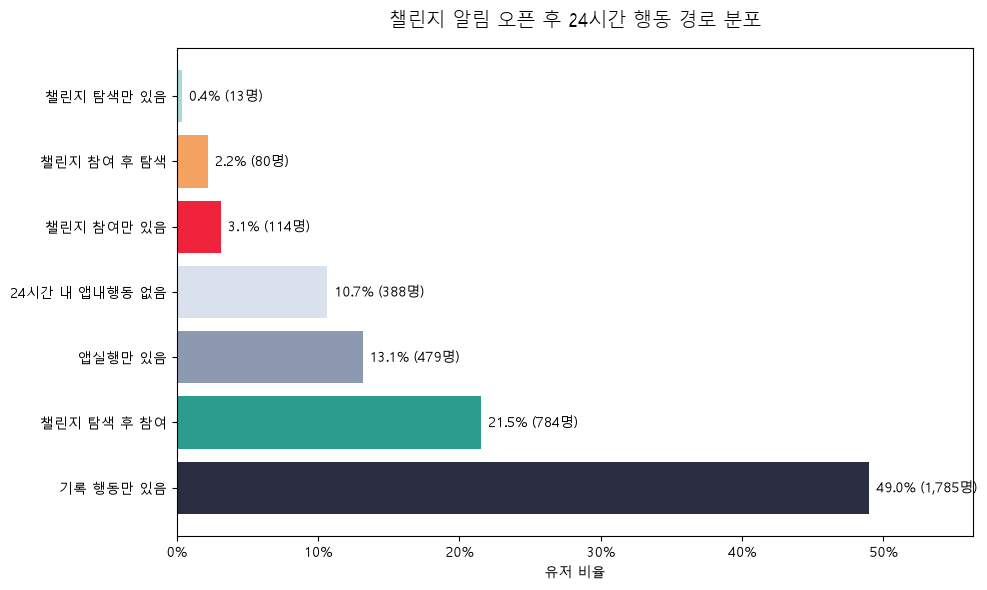

In [ ]:
# 오픈 후 24시간 행동 경로 분포
path_plot = path_summary.copy()

# 보고서용 순서 재정렬
path_order = [
    "기록 행동만 있음",
    "챌린지 탐색 후 참여",
    "앱실행만 있음",
    "24시간 내 앱내행동 없음",
    "챌린지 참여만 있음",
    "챌린지 참여 후 탐색",
    "챌린지 탐색만 있음"
]

path_plot["path_24h"] = pd.Categorical(
    path_plot["path_24h"],
    categories=path_order,
    ordered=True
)

path_plot = path_plot.sort_values("path_24h").copy()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    path_plot["path_24h"],
    path_plot["ratio"],
    color=[MAIN, ACCENT, SUB, LIGHT, ACCENT2, "#F4A261", "#A8DADC"]
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, path_plot["ratio"].max() * 1.15)

ax.set_title("챌린지 알림 오픈 후 24시간 행동 경로 분포", fontsize=14, pad=15)
ax.set_xlabel("유저 비율")
ax.set_ylabel("")

for bar, ratio, n in zip(bars, path_plot["ratio"], path_plot["user_count"]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{ratio:.1%} ({n:,}명)",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

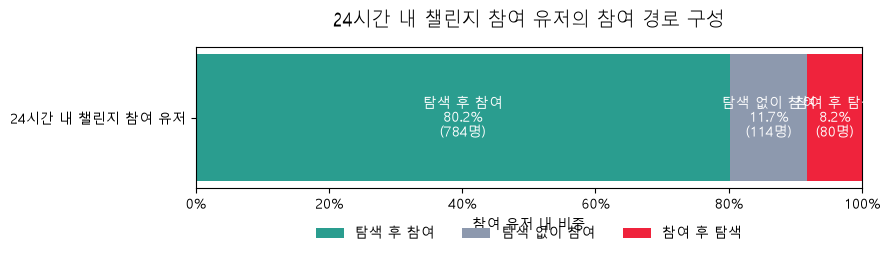

In [26]:
# 챌린지 참여 유저의 참여경로 구성
join_plot = join_path_summary.copy()

join_order = ["탐색 후 참여", "탐색 없이 참여", "참여 후 탐색"]
join_plot["join_type"] = pd.Categorical(
    join_plot["join_type"],
    categories=join_order,
    ordered=True
)
join_plot = join_plot.sort_values("join_type").copy()

fig, ax = plt.subplots(figsize=(9, 2.8))

left = 0
colors = [ACCENT, SUB, ACCENT2]

for _, row, color in zip(join_plot.index, join_plot.itertuples(), colors):
    ax.barh(
        ["24시간 내 챌린지 참여 유저"],
        [row.ratio_among_join_users],
        left=left,
        color=color,
        label=row.join_type
    )
    ax.text(
        left + row.ratio_among_join_users / 2,
        0,
        f"{row.join_type}\n{row.ratio_among_join_users:.1%}\n({row.user_count:,}명)",
        ha="center",
        va="center",
        fontsize=10,
        color="white" if row.ratio_among_join_users > 0.08 else "black"
    )
    left += row.ratio_among_join_users

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("24시간 내 챌린지 참여 유저의 참여 경로 구성", fontsize=14, pad=15)
ax.set_xlabel("참여 유저 내 비중")
ax.set_ylabel("")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

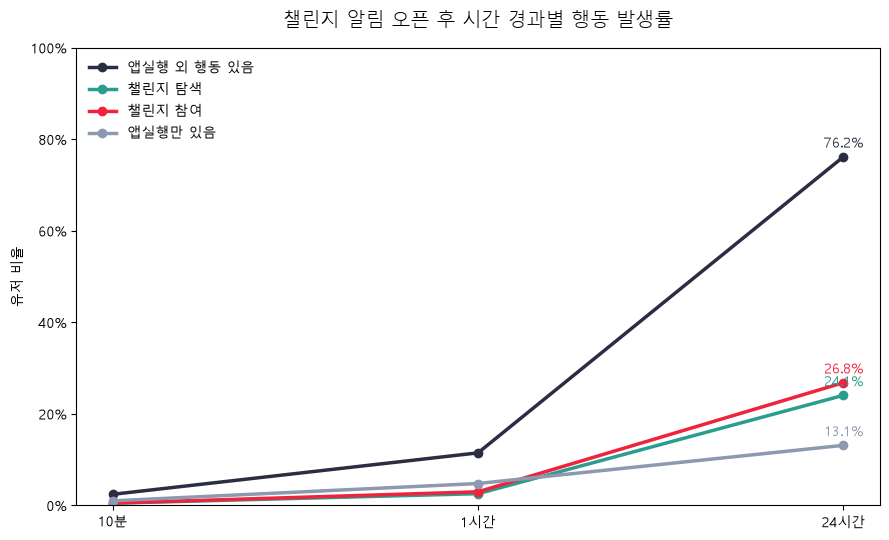

In [27]:
# 시간 경과별 행동 발생률

ws = window_summary.copy()

# 보기 좋은 라벨로 변경
window_map = {
    "10분": "10분",
    "60분": "1시간",
    "1440분": "24시간"
}
ws["window_label"] = ws["window"].replace(window_map)

# 순서 고정
ws["window_label"] = pd.Categorical(
    ws["window_label"],
    categories=["10분", "1시간", "24시간"],
    ordered=True
)
ws = ws.sort_values("window_label")

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(ws["window_label"], ws["has_non_launch_event_rate"], marker="o", linewidth=2.5, color=MAIN, label="앱실행 외 행동 있음")
ax.plot(ws["window_label"], ws["challenge_explore_rate"], marker="o", linewidth=2.5, color=ACCENT, label="챌린지 탐색")
ax.plot(ws["window_label"], ws["challenge_join_rate"], marker="o", linewidth=2.5, color=ACCENT2, label="챌린지 참여")
ax.plot(ws["window_label"], ws["only_app_launch_rate"], marker="o", linewidth=2.5, color=SUB, label="앱실행만 있음")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.0)

ax.set_title("챌린지 알림 오픈 후 시간 경과별 행동 발생률", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("유저 비율")
ax.legend(frameon=False)

# 값 라벨 (주요 24시간 값만)
last_x = ws["window_label"].iloc[-1]
for col, color in [
    ("has_non_launch_event_rate", MAIN),
    ("challenge_explore_rate", ACCENT),
    ("challenge_join_rate", ACCENT2),
    ("only_app_launch_rate", SUB),
]:
    y = ws[col].iloc[-1]
    ax.text(last_x, y + 0.02, f"{y:.1%}", color=color, fontsize=10, ha="center")

plt.tight_layout()
plt.show()

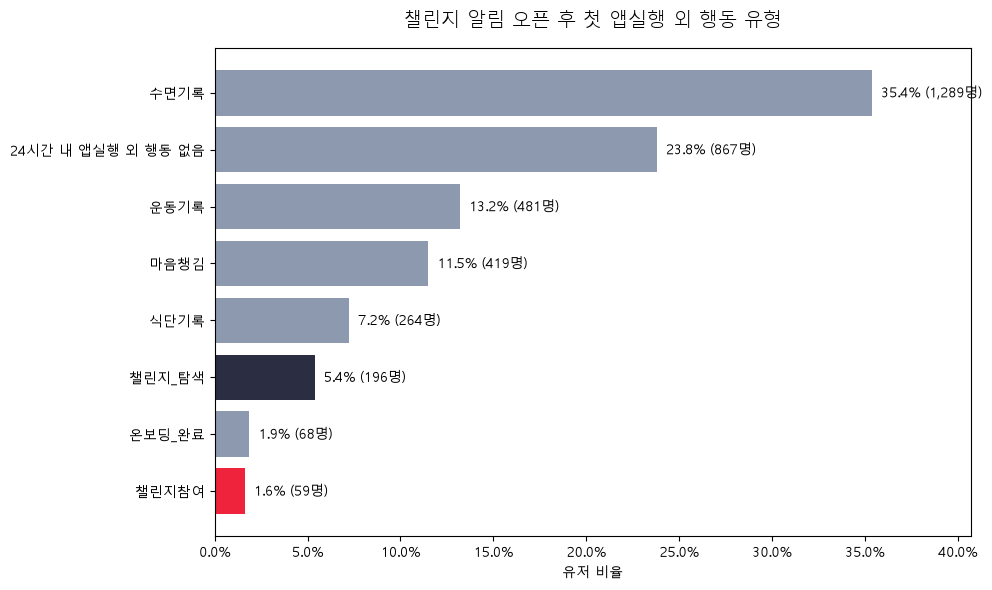

In [28]:
# 첫 앱실행 외 행동 유형 분포
first_non_plot = first_non_launch_summary.copy()

# 너무 긴 이름 정리 원하면 가능
first_non_plot = first_non_plot.sort_values("ratio", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    first_non_plot["first_non_launch_action_24h"],
    first_non_plot["ratio"],
    color=[MAIN if x == "챌린지_탐색" else ACCENT2 if x == "챌린지참여" else SUB for x in first_non_plot["first_non_launch_action_24h"]]
)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlim(0, first_non_plot["ratio"].max() * 1.15)

ax.set_title("챌린지 알림 오픈 후 첫 앱실행 외 행동 유형", fontsize=14, pad=15)
ax.set_xlabel("유저 비율")
ax.set_ylabel("")

for bar, ratio, n in zip(bars, first_non_plot["ratio"], first_non_plot["user_count"]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{ratio:.1%} ({n:,}명)",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

챌린지 알림을 열어도 49%는 기록 행동으로 들어감     
챌린지 참여 유저는
    - 탐색 후 참여	    784 	80.2%
    - 탐색 없이 참여	114	    11.7%
    - 참여 후 탐색	    80	    8.2%    
##### 전략 제안
1. 알림 클릭 후 랜딩/cta 개선
    - 현재는 알림을 열어도 앱실행이나 기록 행동으로 빠지는 유저가 많음
    - -> 챌린지 알림 클릭 후 일반 홈이 아니라 해당 챌린지 상세 페이지로 연결하도록
2. 기록 행동과 챌린지를 연결
    - 49%가 기록 행동만 있기 때문에 기록 후 자연스럽게 챌린지로 이어지도록
        - 수면기록한 유저에게는 한달 수면 챌린지
        - 운동기록 유저에게는 운동 루틴 챌린지 등 맞춤 추천
3. 앱실행만 하고 끝난 유저 
    - 앱실행만 함               13.1%
    - 24시간 내 앱내 행동 없음   10.7%
    - -> 챌린지 알림 클릭 후 진입 화면의 메시지, cta, 혜택 설명, 챌린지 위치 노출 등 전면 개선 필요

